# Task 5: Personal Loan Acceptance Prediction

**Objective:** Predict which customers are likely to accept a personal loan offer 
based on their demographic and financial information. 

This notebook follows a structured approach:
1. Dataset Understanding
2. Data Cleaning & Preparation
3. Exploratory Data Analysis (EDA)
4. Model Training & Evaluation
5. Conclusion


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
%matplotlib inline


## Dataset Loading

We load the Bank Marketing dataset from the `data` folder.
This dataset contains customer demographics, financial information, and 
whether they accepted the personal loan offer (target variable).


In [4]:
df = pd.read_csv("data/bank.csv")
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Dataset Understanding

In this step, we explore the structure of the Bank Marketing dataset. 
We examine the number of rows and columns, column names, and the first few rows.
This helps us understand the features available and the target variable.


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
df.head()


Dataset Shape:
(11162, 17)

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Data Cleaning & Preparation

In this step, we clean the dataset and prepare it for modeling:

- Handle missing values (if any)
- Encode categorical variables such as `job`, `marital`, and `education`
- Separate features (`X`) and target (`y`) for the model


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [8]:
# Encode categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['job', 'marital', 'education'], drop_first=True)

# Define features and target
X = df_encoded.drop('deposit', axis=1)  # 'deposit' is the target column
y = df_encoded['deposit'].map({'yes': 1, 'no': 0})  # convert target to numeric


### Age Distribution by Loan Acceptance

We examine how the age of customers relates to personal loan acceptance. 
This histogram shows the number of customers who accepted or did not accept 
the loan across different age groups.


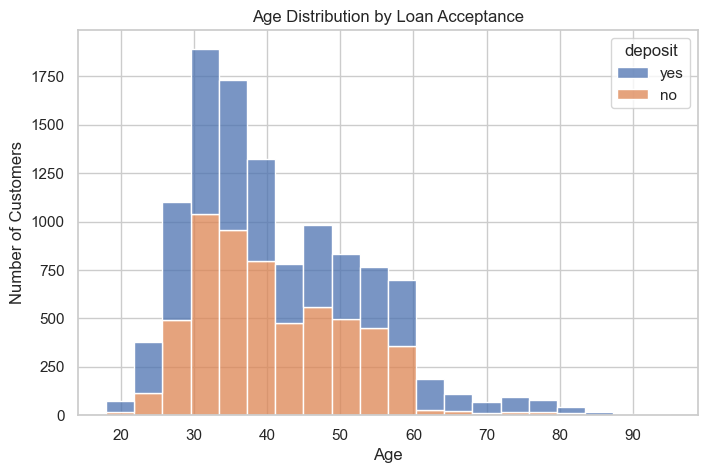

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='deposit', multiple='stack', bins=20)
plt.title('Age Distribution by Loan Acceptance')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()


### Balance Distribution by Loan Acceptance

Next, we analyze how the customers' account balance affects the likelihood 
of accepting a personal loan. Higher or lower balances may show patterns 
in loan acceptance.


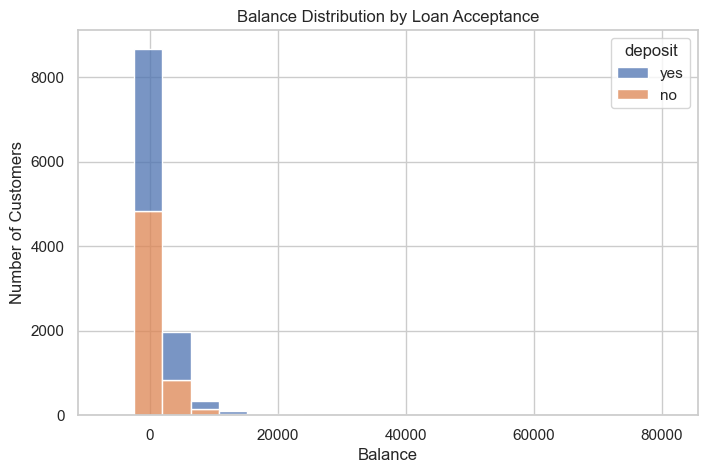

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='balance', hue='deposit', multiple='stack', bins=20)
plt.title('Balance Distribution by Loan Acceptance')
plt.xlabel('Balance')
plt.ylabel('Number of Customers')
plt.show()


### Job vs Loan Acceptance

This count plot visualizes which job types are more likely to accept 
a personal loan. It helps identify customer segments with higher acceptance rates.


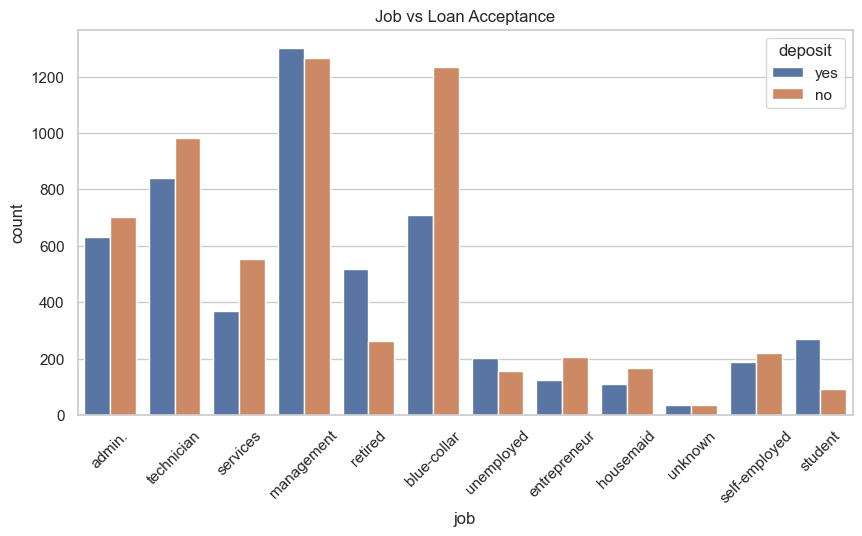

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(x='job', hue='deposit', data=df)
plt.xticks(rotation=45)
plt.title('Job vs Loan Acceptance')
plt.show()


## Logistic Regression Model

In this step, we train a Logistic Regression model to predict which customers 
are likely to accept a personal loan. 

We will:
1. Split the data into training and test sets
2. Train the model on the training data
3. Make predictions on the test data
4. Evaluate performance using accuracy and confusion matrix


In [13]:
# Identify categorical columns that are still strings
cat_cols = X.select_dtypes(include='object').columns
print("Categorical columns to encode:", cat_cols)

# Encode them using one-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)


Categorical columns to encode: Index(['default', 'housing', 'loan', 'contact', 'month', 'poutcome'], dtype='object')


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)  # increase iterations to ensure convergence
model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

After training the Logistic Regression model, we evaluate its performance using:

- **Accuracy**: Measures the overall correctness of the predictions.
- **Confusion Matrix**: Shows the counts of True Positives, True Negatives, 
  False Positives, and False Negatives, which helps us understand where the model is making mistakes.

We use the scaled test set for evaluation to ensure consistent results.


In [19]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(cm)


Accuracy: 0.81
Confusion Matrix:
[[972 194]
 [234 833]]
